In [1]:
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
T = 5

def f1(t):
    return t

def m1(t):
    return t**2 / 2

def f2(t):
    return t**4

def m2(t):
    return t**5 / 5

def f3(t):
    return np.sin(t)**2

def m3(t):
    return (t - np.sin(t) * np.cos(t)) / 2

In [4]:
def metoda1(f):
    t, I = 0, 0
    jumps = []
    M = max(f(np.linspace(0, T, 100))) + 0.0001
    while True:
        U1 = np.random.uniform(0,1)
        t = t - np.log(U1) / M
        if t > T:
            break
        U2 = np.random.uniform(0,1)
        if U2 < f(t) / M:
            I += 1
            jumps.append(t)
    return jumps
print(metoda1(f1))

[0.934515225386896, 3.2358826564815306, 3.6357998762454597, 4.2057804340821825, 4.3201771598597185, 4.532147949916801, 4.881191061010807]


In [19]:
def metoda2(f, F):
    t, I = 0, 0
    jumps = []
    while True:
        U1 = np.random.uniform(0, 1)
        t = F(U1)
        if t > T:
            break
        I += 1
        jumps.append(t)
    return jumps

Zadanie 2: Metoda odwrotnej dystrybuanty

In [20]:
def zad2(m, t, T):
    NT = np.random.poisson(m(T))
    t = np.linspace(0, T, NT)
    F = m(t) / m(T)
    return F

Zadanie 3: Suma dwóch procesów Poissona

<Axes: ylabel='Density'>

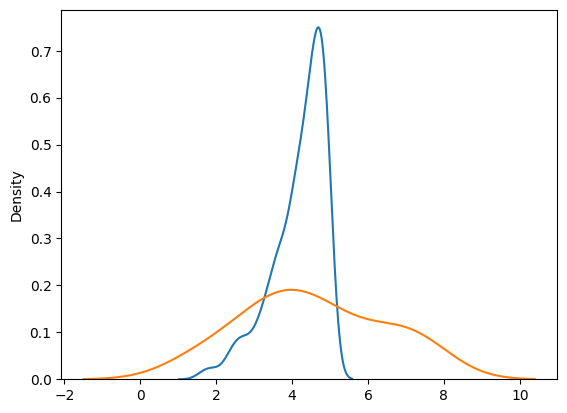

In [29]:
def f12(t):
    return t + t**4

intensity = metoda1(f12)
intensity1 = metoda1(f1)
intensity2 = metoda1(f2)
intensity_sum = [intensity1[i] + intensity2[i] for i in range(min(len(intensity2), len(intensity1)))]
sn.kdeplot(intensity)
sn.kdeplot(intensity_sum)

Zadanie 4: Złożony proces Poissona - podstawowa implementacja

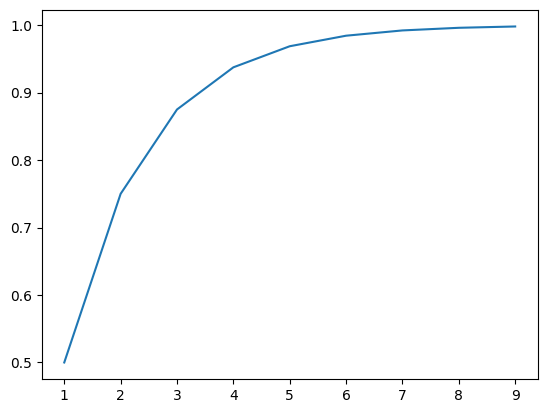

In [31]:
def F(k, p):
    return (1 - p)**(k - 1) * p

def zad4(T, Fz):
    if T <= 0:
        return 0
    
    lista = [Fz(i, 1/2) for i in range(1, T)]
    Y = []
    for i in range(len(lista)):
        Y.append(np.sum(lista[:i+1]))
    
    plt.plot(range(1, len(Y) + 1), Y)
    plt.show()


zad4(10, F)

Zadanie 5: Funkcja charakterystyczna